In [ ]:
source("../utils.R")

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject

Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Loading required package: ensembldb

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated

In [ ]:
data <- LoadH5Seurat("../../report/obj_all.h5seurat")
tb_data <- subset(data, group_ == 'tb')
tb_data <- subset(tb_data,cell_type_tb2 %in% c('CD4+ Naive T','CD4+ Memory T','CD4+ Cytotoxic T',
                                               'CD8+ Naive T','CD8+ Memory T','CD8+ Cytotoxic T',
                                               'gdT','MAIT','Treg','DP T'))
tb_celltype_marker <- list(
  # B = c('CD79A'),
  # Plasmablast = c('MZB1'),
  CD4 = c('CD3D','CD4'),
  CD8 = c('CD8A','GNLY','GZMK','GZMB','TRGV9'),
  Treg=c("IKZF2"),
  Naive = c("IL7R","CCR7","SELL","TCF7"),
  NK = c('NKG7','NCAM1'),
  MAIT = c('SLC4A10')
  # Monocyte = c('CD14','FCGR3A','S100A9'),
  # cDC=c("HLA-DQA1","HLA-DQB1"),
  # pDC = c('IRF7'),
  # Platelets=c("PPBP"),
  # RBC = c('HBB'),
  # HSC=c("CD34") 
)
p1 <- DotPlot(tb_data,
        assay = 'rna',
        features = unique(c(list_c(tb_celltype_marker),"SLC4A10")),
        group.by = "cell_type_tb2")+
  coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

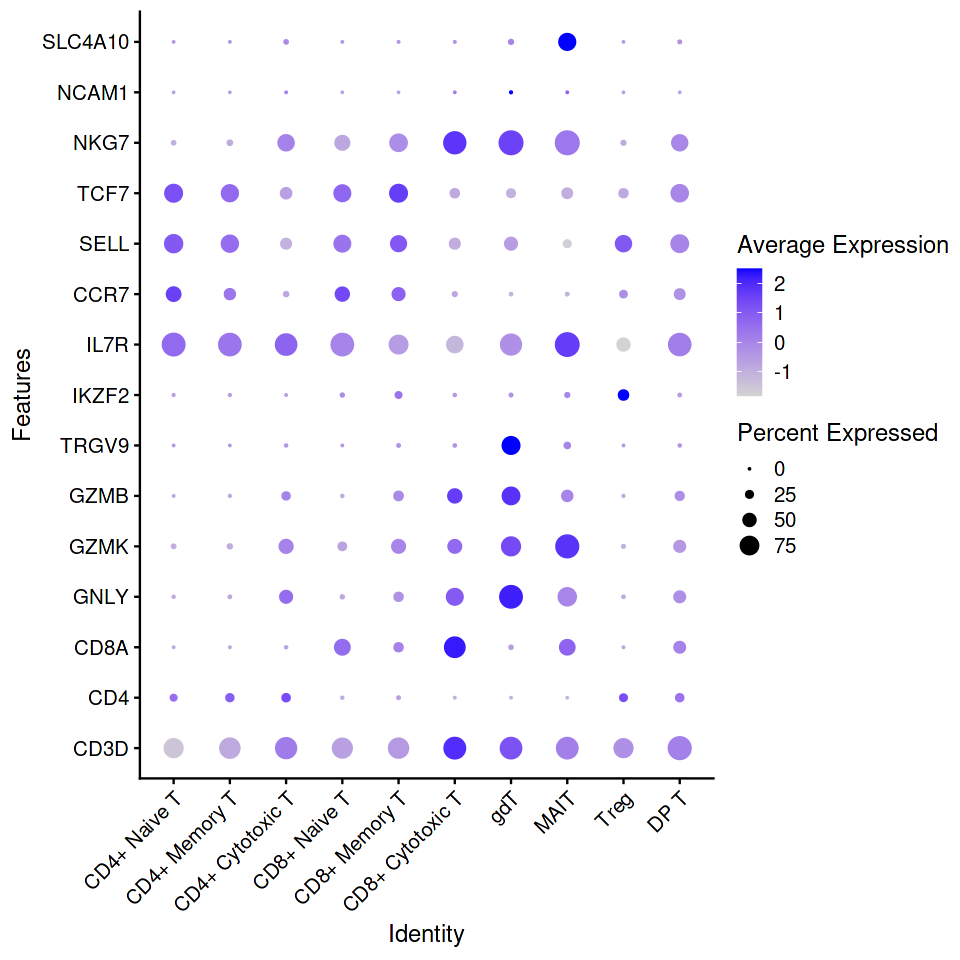

In [7]:
options(repr.plot.width = 8, repr.plot.height = 8)
p1

In [ ]:
p2 <- subset(tb_data,cell_type_tb2 %in% c("CD4+ Naive T","CD4+ Memory T", "CD4+ Cytotoxic T",
                                    "CD8+ Naive T", "CD8+ Memory T", "CD8+ Cytotoxic T",
                                    "gdT", "MAIT","NK T", "Treg","T_HERC1","DP T",
                                    "NK CD56hi","NK CD56low")) |>
  VlnPlot(,
          sort = T,
          assay = 'adt',
          features = 'tcr.v.7.2',
          pt.size = 0,
          group.by = "cell_type_tb2",
          raster = F)

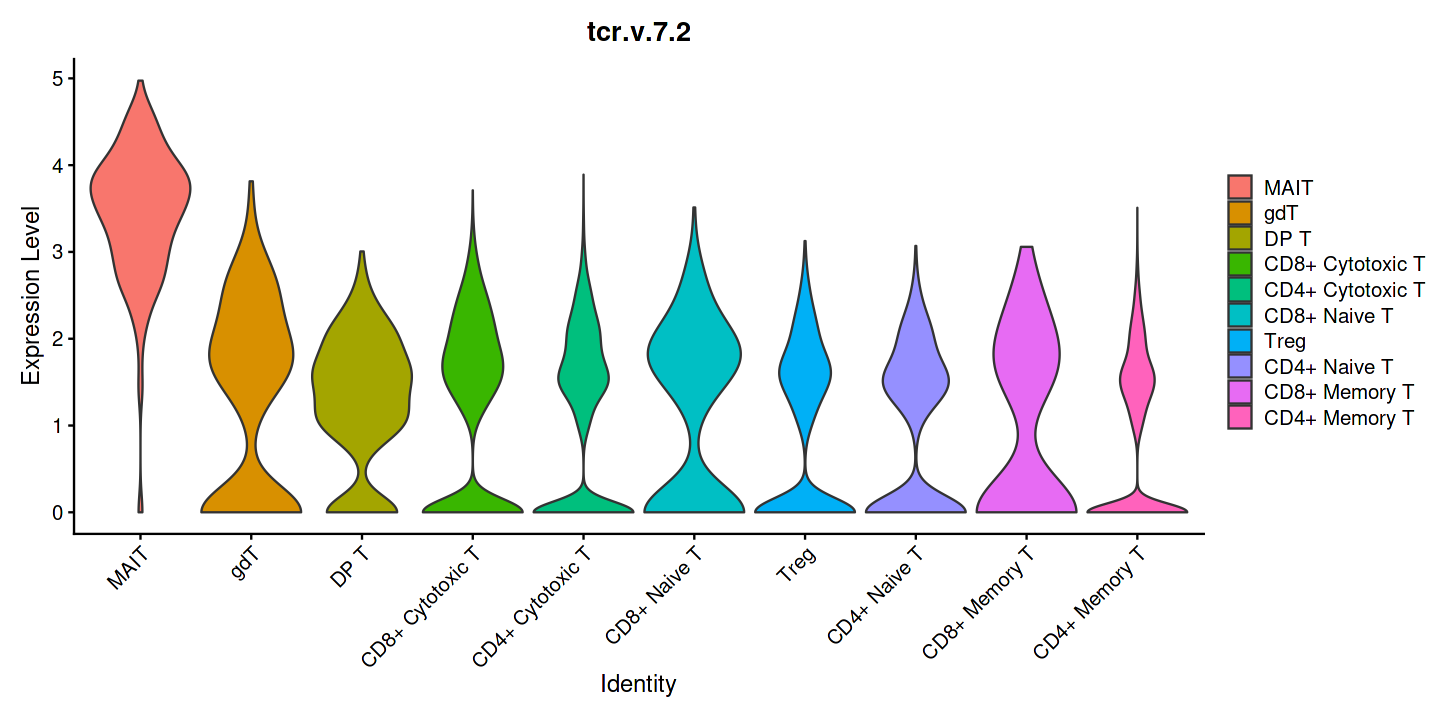

In [10]:
options(repr.plot.width = 12, repr.plot.height = 6)
p2

Warning message:
"ggrepel: 4 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


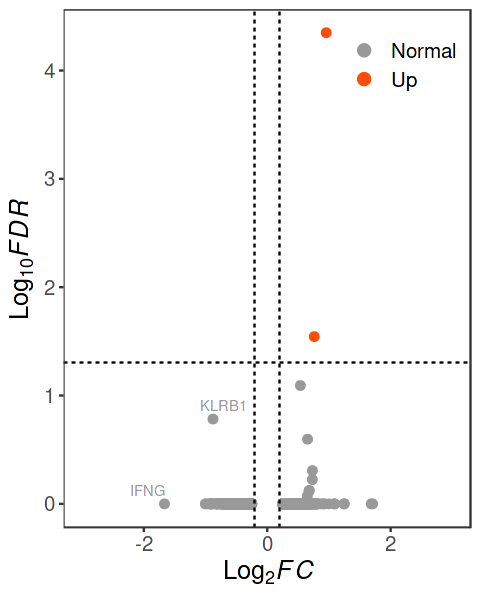

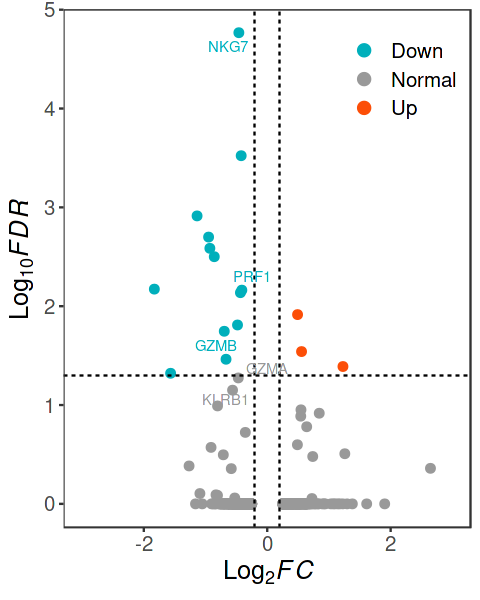

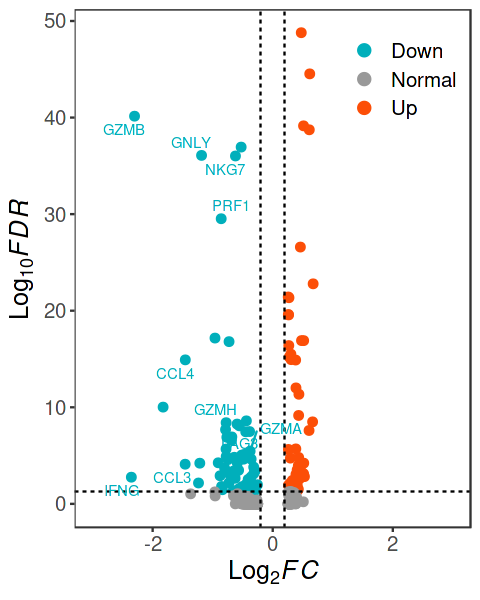

In [16]:
library(tidyr)
library(ggpubr)
library(ggVolcano)
options(repr.plot.width = 4, repr.plot.height = 5)

iav_deg_mait_rna <- read_rds('./iav_deg_mait_rna.rds')
covid_deg_mait_rna <- read_rds('./covid_deg_mait.rds')
tb_deg_mait_rna <- read_rds('./tb_deg_mait_rna.rds')
p3 <- ggvolcano(iav_deg_mait_rna, 
          x = "log2FoldChange", y = "padj",
          fills =  c("#999999", "#FC4E07"),
          colors = c("#999999", "#FC4E07"),
          label = "row", 
          label_number = 0,
          legend_position = 'UR',
          pointSize = 2,
          custom_label = c("IFNG","GZMB","CCL3","CCL4","GZMK","GZMB",
                           "KLRB1"),
          log2FC_cut = 0.2,
          FDR_cut = 0.05,
          output=F,filename = 'volcano_plot')+
  xlim(-3,3)+
  theme(panel.grid = element_blank(),
        legend.title = element_blank())


p4 <- ggvolcano(covid_deg_mait_rna, 
          x = "log2FoldChange", y = "padj",
          label = "row", 
          label_number = 0,
          legend_position = 'UR',
          pointSize = 2,
          custom_label = c("IFNG","GZMB","NKG7","PRF1","CCL4","GZMA",
                           "KLRB1","LAG3"),
          log2FC_cut = 0.2,
          FDR_cut = 0.05,
          output=F,filename = 'volcano_plot')+
  xlim(-3,3)+
  theme(panel.grid = element_blank(),
        legend.title = element_blank())

p5 <- ggvolcano(tb_deg_mait_rna, 
          x = "log2FoldChange", y = "padj",
          label = "row", 
          label_number = 0,
          legend_position = 'UR',
          pointSize = 2,
          custom_label = c("IFNG","GZMB","CCL3","CCL4","GNLY","LAG3",
                           "PRF1","NKG7","GZMH","GZMA"),
          log2FC_cut = 0.2,
          FDR_cut = 0.05,
          output=F,filename = 'volcano_plot')+
  xlim(-3,3)+
  theme(panel.grid = element_blank(),
        legend.title = element_blank())
p3
p4
p5